<a href="https://colab.research.google.com/github/nicolaheld24/CloudComputing/blob/main/Copy_of_CloudComp_Bavaria_NDVI_Forest_Held.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NDVI Trend Analysis in Bavarian Forests between 2013 and 2025

## 1. Data Preparation

### 1.1 Import Required Libraries

In [1]:
#!pip install xee
!pip install cartopy
#!pip install rioxarray
#!pip install geodatasets matplotlib_scalebar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 81.4 MB/s eta 0:00:00


In [2]:
import ee
import geemap
from geemap import cartoee
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.lines as mlines # Import mpatches for custom legend handles
import cartopy.crs as ccrs
from cartopy.mpl.geoaxes import GeoAxes
import seaborn as sns


### 1.2 Create Linkage between Python notebook & GEE

In [3]:
ee.Authenticate()
ee.Initialize(project="propane-tribute-464707-b2") # link Python notebook to your GEE project

### 1.3 Load Bavaria Boundary & Creative Interactive Map

In [4]:
# Load Germany administrative boundaries (Level 1 = states/provinces)
germany = ee.FeatureCollection("FAO/GAUL/2015/level1") \
  .filter(ee.Filter.eq("ADM0_NAME", "Germany"))

# Extract Bavaria from Germany (ADM1 = state level)
bavaria = germany.filter(ee.Filter.eq("ADM1_NAME", "Bayern"))

# Load Germany districts (Level 2 = smaller administrative units)
germany_level2 = ee.FeatureCollection("FAO/GAUL/2015/level2")
bavaria_districts = germany_level2.filter(ee.Filter.eq("ADM1_NAME", "Bayern"))

# Create an interactive map using geemap
Map = geemap.Map(basemap='HYBRID', ee_initialize=False) # 'HYBRID' = satellite imagery + labels
Map.addLayer(bavaria, {}, "Bavaria") # Add Bavaria boundary layer to the map
Map.centerObject(bavaria, 7)
Map

Map(center=[48.942113170079146, 11.422125063138433], controls=(WidgetControl(options=['position', 'transparent…

In [5]:
# Boundaries of Bavaria
bavaria_outline = ee.Image().paint(
    featureCollection=bavaria,
    color=1,
    width=5
).visualize(palette=['black'])

# Boundaries of Districts of Bavaria
districts_outline = ee.Image().paint(
    featureCollection=bavaria_districts,
    color=1,
    width=1
).visualize(palette=['black'])

# Convert EE FeatureCollections to GeoDataFrames for plotting / analysis
bavaria_gdf = geemap.ee_to_gdf(bavaria)
districts_gdf = geemap.ee_to_gdf(bavaria_districts)


### 1.4 Load Land Cover & Forest Mask

In [6]:
# Load ESA WorldCover 2021 landcover dataset
landcover = ee.Image("ESA/WorldCover/v200/2021")

# Select forest pixels (class 10), clip to Bavaria, mask non-forest areas
forest = landcover.select('Map').eq(10).clip(bavaria).selfMask()

# Add forest layer to the map for visualization
Map.addLayer(forest, {'palette': 'green'}, 'Forest areas')

### 1.5 Load Landsat Collection & Apply Cloud Masking

In [7]:
# Function to mask out cloudy or non-clear pixels using the QA_PIXEL band
def mask_landsat(image):
    qa = image.select("QA_PIXEL")

    # Bit 6 indicates clear pixels (1 = clear); create mask
    mask = qa.bitwiseAnd(1 << 6).neq(0)
    # Apply mask to the image
    return image.updateMask(mask)

In [8]:
# Load Landsat 8 surface reflectance collection, filter to Bavaria and 2013-2025
# Apply cloud/QA mask to each image
landsat = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterBounds(bavaria) \
    .filterDate('2013-01-01', '2025-10-31') \
    .map(mask_landsat)


### 1.6 Add NDVI Function

In [9]:
# Function to calculate NDVI from Landsat surface reflectance bands
def calcNDVI(image):
  ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI') # NDVI = (NIR - Red) / (NIR + Red), Landsat 8: NIR=SR_B5, Red=SR_B4
  return image.addBands(ndvi) # Add NDVI as a new band to the image


## 2. Annual NDVI Composites

### 2.1 Create Yearly Composites

In [10]:
# List of years for analysis (2013–2025)
years = list(range(2013, 2026)) # ends always with year after, so that 2025 is still included

# Function to create annual NDVI composite for a given year
def create_annual_composite(year):
  # Define growing season (April–October)
  start = ee.Date.fromYMD(year,4,1)
  end = ee.Date.fromYMD(year,10,31)

  # Filter Landsat images for the year, compute NDVI
  yearly = (landsat
        .filterDate(start, end)
        .map(calcNDVI)
        .select('NDVI'))

  # Create median NDVI composite, mask non-forest pixels, clip to Bavaria
  composite = (yearly.median()
        .updateMask(forest) # keeps only pixels of forest // masks out other pixels
        .clip(bavaria)
        .set('year', year) # saves year in image // stores metadata
        .set('system:time_start', start.millis()))

  # Add a 'time' band for trend analysis
  timeBand = ee.Image.constant(year).toFloat().rename('time')

  return composite.addBands(timeBand)

# Combine all yearly composites into a single ImageCollection
annualNDVI = ee.ImageCollection.fromImages(
    [create_annual_composite(y) for y in years]
)

annualNDVI

### 2.2 Create Maps of Annual NDVI Mean

In [ ]:
# Set global font for all plots
plt.rcParams['font.family'] = 'serif' # Globally changed font to "serif" for all texts in notebook

# Define years for analysis (2013–2025)
years = list(range(2013, 2026))
n_years = len(years)

# Grid layout for subplots
n_cols = 4 # number of columns
n_rows = (n_years + n_cols - 1) // n_cols # number of rows

# Bounding box of Bavaria
bavaria_region = [13.9, 47.2, 8.9, 50.6]

# NDVI visualization parameters
vis = {'min':0,'max':0.6,'palette': ['#440154', '#414487', '#2a788e', '#22a884', '#7ad151', '#fde725']}

# Create matplotlib figure with Cartopy projections
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 5*n_rows),
    subplot_kw={'projection': ccrs.PlateCarree()}
  )

axes = axes.flatten() # flatten to 1D array for easy iteration

# Convert Earth Engine ImageCollection to Python list for iteration
img_list = annualNDVI.toList(n_years)

for i, year in enumerate(years):
    img = ee.Image(img_list.get(i))
    ax = axes[i]

    # Add NDVI layer to subplot
    cartoee.add_layer(
        ax,
        img.select('NDVI'),
        region=bavaria_region,
        dims=800,   # Spatial resolution for less computing time
        vis_params = vis)

    ax.set_aspect(1.5) # set aspect to avoid map distortion

    # Add gridlines
    gl = ax.gridlines(draw_labels=True)

    # Compute subplot column and row
    gl.left_labels = True
    gl.bottom_labels = True
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(f"{year}", fontsize=12) # Add year as subplot title

for j in range(i+1, n_rows*n_cols): # Remove unused subplots if grid is larger than number of years
    fig.delaxes(axes[j])

# Create a custom colorbar axis outside the figure
cax = fig.add_axes([0.3, 0.1, 0.4, 0.02])  # [left, bottom, width, height]

# Create colorbar for NDVI values
norm = plt.Normalize(vmin=vis['min'], vmax=vis['max'])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])  # # required for ScalarMappable
cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation='horizontal',
    ticks=[0,0.1,0.2,0.3,0.4,0.5],
    extend='both'
)
cbar.set_label("NDVI", fontsize=12)

# Main title for the entire figure
plt.suptitle("Yearly Median NDVI in Bavarian Forests between 2013-2025", fontsize=18)

# Adjust spacing to fit colorbar and title
plt.subplots_adjust(right=0.5, top=0.4, hspace=0.8, wspace=0.3)
plt.tight_layout(rect=[0, 0, 0.98, 0.97]) #rect=[left, bottom, right, top] # Creates extra space so that tight_layout() doesn´t overwrite the other settings from before

# Save figure
plt.savefig("Annual_NDVI_Bavaria_maps_2013_2025.png", dpi=300)

plt.show()

### 2.3 Single Median NDVI Map (overall period)

In [ ]:
# Median NDVI map for Bavaria (2013–2025)

fig = plt.figure(figsize=(10,8))

bavaria_region = [13.9, 47.2, 8.9, 50.6] # Bounding box of Bavaria

# NDVI visualization parameters (median values)
median_vis = {"min": 0.2, "max": 0.5, "palette": ['#8B4513', '#FFFF00', '#008000']}

# Get map with Cartopy projection using annual NDVI ImageCollection
ax = cartoee.get_map(
    annualNDVI.select('NDVI'),
    region=bavaria_region,
    vis_params=median_vis,
    proj=ccrs.PlateCarree() # Re-adding the projection to ensure GeoAxes
)

ax.set_aspect(1.5) # prevent distortion

# Add vertical colorbar on the right
cbar = cartoee.add_colorbar(
    ax, median_vis,
    loc='right',
    label="Median NDVI"
)

# Add north arrow in top-right corner
cartoee.add_north_arrow(
    ax,
    xy=(0.93, 0.93),   # Top right corner
    text="N",
    fontsize=10,       # smaller font for the "N"
    arrow_length=0.06, # optional: scales the arrow itself
    width=2,
    headwidth=7)   # optional: thinner arrow

# Add scale bar in top-right corner
cartoee.add_scale_bar_lite(
    ax,
    xy=(0.8, 0.9), # position of scalebar
    unit="km",
    fontsize=15)

# Add gridlines with labels only on left and bottom
gl = ax.gridlines(draw_labels=True)
gl.bottom_labels = True
gl.left_labels   = True
gl.top_labels    = False
gl.right_labels  = False

# Draw Bavaria boundary (thicker black line)
bavaria_gdf.boundary.plot(
    ax=ax,
    edgecolor='black',
    linewidth=1.5,
    zorder=5             # order of layering
)

# Draw districts inside Bavaria (thinner black lines)
districts_gdf.boundary.plot(
    ax=ax,
    edgecolor='black',
    linewidth=0.6,
    zorder=4
)

# Add main title
ax.set_title(label="Median NDVI in Bavarian Forests (2013-2025)", fontsize=15)

# Create legend handles for Bavaria and districts
bavaria_line = mlines.Line2D([], [], color='black', linewidth=1.5, label='Bavarian Boundary')
district_line = mlines.Line2D([], [], color='black', linewidth=0.6, label='Bavarian Districts', alpha=0.7)

# Add legend to map
ax.legend(handles=[bavaria_line, district_line],
          loc='lower right', fontsize=10, frameon=True)

plt.tight_layout()

# Save figure to file
plt.savefig("median_NDVI_Bavaria.png", dpi=300)

plt.show() # Show figure

### 2.4 Timelapse of NDVIs per year

In [ ]:
# Generate NDVI timelapse GIF for Bavarian forests

# Output directory and GIF filename
out_dir = "timelapse"
out_gif = "NDVI_Bavaria_forest.gif"

bavaria_region = [13.9, 47.2, 8.9, 50.6]  # Bounding box for Bavaria

# Visualization parameters for NDVI values
vis_params = {"palette": ['brown', 'yellow', 'green'], "min": 0, "max": 0.5}

# Create animated timelapse of annual NDVI
cartoee.get_image_collection_gif(
    ee_ic=annualNDVI.select('NDVI'), # ImageCollection of annual NDVI
    out_dir=out_dir,
    out_gif=out_gif,
    vis_params=vis_params,
    region=bavaria_region,
    aspect=1.5,
    fps=3,                      # Frames per second
    grid_interval=(1, 1),       # optional: grid lines
    plot_title="NDVI - ",       # Title prefix per frame
    date_format='YYYY',
    fig_size=(10, 8),           # Display year on each frame
    dpi_plot=300,               # Resolution of each frame
    file_format="jpg",
    plot_colorbar=True,         # Add colorbar
    colorbar_label="NDVI",      # Label for colorbar
    verbose=True,
)

# Display the generated GIF directly in notebook
geemap.show_image(f'{out_dir}/{out_gif}')

### 2.5 Monthly NDVI Time Series

#### 2.5.1 Extract monthly and annual NDVIs

Extract monthly NDVI and convert to pandas dataframe

In [ ]:
months = list(range(4, 11)) # ends always with year after, so that 2025 is still included

def create_monthly_composite(year, month):
  start = ee.Date.fromYMD(year, month,1)
  end = start.advance(1, 'month').advance(-1, 'day') # not every month ends with 30 days

  monthly = (landsat
        .filterDate(start, end)
        .map(calcNDVI)
        .select('NDVI'))

  composite = (monthly.median()
        .updateMask(forest) # keeps only pixels of forest // masks out other pixels
        .clip(bavaria)
        .set('year', year) # saves year in image
        .set('month', month)
        .set('system:time_start', start.millis()))

  timeBand = ee.Image.constant(year + (month-1)/12).toFloat().rename('time')

  return composite.addBands(timeBand)

# Combining mean NDVIs to ImageCollection containing years
monthly_NDVI = ee.ImageCollection.fromImages(
    [create_monthly_composite(y, m) for y in years for m in months])

monthly_NDVI

In [ ]:
#extract monthly NDVI

def extract_monthly_ndvi(image):
  stats = image.reduceRegion(
      reducer = ee.Reducer.mean(),
      geometry = bavaria,
      scale = 100,
      maxPixels = 1e13
  )
  return ee.Feature(None, {
      'year': image.get('year'),
      'month': image.get('month'),
      'mean_NDVI': stats.get('NDVI')
  })

monthly_features = monthly_NDVI.map(extract_monthly_ndvi)
monthly_df = geemap.ee_to_df(ee.FeatureCollection(monthly_features))


Extract Annual Mean and convert to pandas dataframe

In [ ]:
# Extract Annual Mean NDVI for Bavarian Forests
# Compute mean NDVI for the whole Bavaria forest area for a single year.
# Returns an ee.Feature with 'year' and 'mean_NDVI' attributes.
def extract_ndvi(image):
  stats = image.reduceRegion(
      reducer = ee.Reducer.mean(),      # Compute mean NDVI across all pixels
      geometry = bavaria,
      scale = 100,                      # Spatial resolution in meters
      maxPixels = 1e13                  # Allow processing of large datasets
  )
  return ee.Feature(None, {
      'year': image.get('year'),        # Store year of composite
      'mean_NDVI': stats.get('NDVI')    # Store mean NDVI
  })

# Apply function over annual NDVI collection
meanNDVI = annualNDVI.map(extract_ndvi)

# Extract lists of NDVI values and years
ndvi_values = meanNDVI.aggregate_array('mean_NDVI').getInfo()
date = meanNDVI.aggregate_array('year').getInfo()

# Convert to pandas DataFrame for plotting/analysis
annual_df = geemap.ee_to_df(ee.FeatureCollection(meanNDVI))
annual_df


#### 2.5.2 Plots Monthly NDVI with Annual Mean on top

In [ ]:
# Monatliche NDVI-Daten: monthly_df
# Group by year → mean & std
monthly_stats = monthly_df.groupby('year')['mean_NDVI'].agg(['mean','std']).reset_index()

plt.figure(figsize=(10,5))

# Jahresmittel (blau)
plt.plot(annual_df['year'], annual_df['mean_NDVI'], marker='o', label='Annual Mean')

# Monatliche Variation als shaded area (orange)
plt.fill_between(
    monthly_stats['year'],
    monthly_stats['mean'] - monthly_stats['std'],
    monthly_stats['mean'] + monthly_stats['std'],
    color='orange',
    alpha=0.3,
    label='Monthly ±1 Std'
)

plt.xlabel("Year")
plt.ylabel("Mean NDVI")
plt.title("NDVI of Forests in Bavaria (2013–2025) with Monthly Variability")
plt.grid(True)
plt.xticks(annual_df['year'])
plt.legend(loc='lower center')

plt.savefig("monthly_ndvi_plot.png", dpi=300)
plt.show()

#### 2.5.3 Boxplots of monthly NDVIs

In [ ]:
# Boxplots of monthly NDVIs
plt.figure(figsize=(12,6))

sns.boxplot(x='year', y='mean_NDVI', data=monthly_df, showmeans = False,
            widths = 0.5, showfliers=False, patch_artist = True,
            medianprops={"color":"white", "linewidth":0.7},
            boxprops={"facecolor": "C0", "edgecolor": "white","linewidth": 0.5},
            whiskerprops={"color": "C0", "linewidth": 1.2},
            capprops={"color": "C0", "linewidth": 1.2}, label="Mean NDVI per year")

plt.xlabel("Growing Season of Year", fontsize = 14)
plt.ylabel("NDVI", fontsize = 14)
plt.title("Monthly Boxplots of NDVI in Bavarian Forests (Apr–Oct in the years 2013–2025)", fontsize = 18)
# Schriftgröße der Achsen-Ticks ändern
plt.tick_params(axis='x', labelsize=12)  # X-Achse
plt.tick_params(axis='y', labelsize=12)  # Y-Achse
plt.grid(True)
plt.legend(loc="lower center")
plt.show()

## 3. Raster Statistics // Pixel-wise Trend Analysis

### 3.1 NDVI Linear Trend


In [11]:
# Calculate pixel-wise NDVI trend over time
# 'time' band = year, 'NDVI' band = annual NDVI
lintrend = annualNDVI.select(['time', 'NDVI']) \
    .reduce(ee.Reducer.linearFit())

# The result has two bands:
# 'scale' = slope (NDVI change per year)
# 'offset' = intercept (NDVI at time 0)

# Add NDVI trend map to interactive map
# Brown → decreasing NDVI, Yellow → stable, Green → increasing NDVI
Map.addLayer(
    lintrend.select('scale'),
    {
        'min': -0.01,
        'max': 0.01,
        'palette': ['brown', 'yellow', 'green']
    },
    "NDVI Linear Trend"
)



In [ ]:
# NDVI Linear Trend Map for Bavaria (2013–2025)
fig = plt.figure(figsize=(10,8))

bavaria_region = [13.9, 47.2, 8.9, 50.6] # Define bounding box of Bavaria

# Visualization parameters for NDVI trend
# Negative slope → decrease, positive slope → increase
trend_vis = {
    'min': -0.01,
    'max': 0.01,
    'palette': ['#e56e38', '#fff0c2', '#fffef2', '#6da48f', '#25424c']
}

# Create map with Cartopy projection using pixel-wise slope
ax = cartoee.get_map(
    lintrend.select('scale'),
    region=bavaria_region,
    vis_params=trend_vis,
    proj=ccrs.PlateCarree() # Re-adding the projection to ensure GeoAxes
)

ax.set_aspect(1.5) # prevent distortion

# Add vertical colorbar outside the map
cbar = cartoee.add_colorbar(
    ax, trend_vis,
    loc='right',
    label="NDVI Trend (change per year)"
)

# Add north arrow in top-right corner
cartoee.add_north_arrow(
    ax,
    xy=(0.93, 0.93),   # Top right corner
    text="N",
    fontsize=10,       # smaller font for the "N"
    arrow_length=0.06, # optional: scales the arrow itself
    width=2,
    headwidth=7   # optional: thinner arrow
)

# Add scale bar in top-right corner
cartoee.add_scale_bar_lite(
    ax,
    xy=(0.8, 0.9), # exact position of scale bar
    unit="km",
    fontsize=15
)

# Add gridlines with labels only on left and bottom
gl = ax.gridlines(draw_labels=True)
gl.bottom_labels = True
gl.left_labels   = True
gl.top_labels    = False
gl.right_labels  = False

# Draw Bavaria boundary (thick black line)
bavaria_gdf.boundary.plot(
    ax=ax,
    edgecolor='black',
    linewidth=1.5,
    zorder=5             # order of layering
)

# Draw districts inside Bavaria (thinner black lines)
districts_gdf.boundary.plot(
    ax=ax,
    edgecolor='black',
    linewidth=0.8,
    zorder=4
)

# Add main title
ax.set_title(label="Trend of NDVI in Bavarian Forests (2013-2025)", fontsize=15)

# Create custom legend for Bavaria and district boundaries
bavaria_line = mlines.Line2D([], [], color='black', linewidth=1.5, label='Bavarian Boundary')
district_line = mlines.Line2D([], [], color='black', linewidth=0.8, label='Bavarian Districts')

ax.legend(handles=[bavaria_line, district_line],
          loc='lower right', fontsize=10, frameon=True)

plt.tight_layout()

# Save figure in high resolution
plt.savefig("lintrend_NDVI_Bavaria.png", dpi=300)

plt.show()

### 3.2 Sen´s Slope Trend

In [12]:
# Sen's Slope requires the independent variable (time/year) as the first band
# Here we reorder bands to [time, NDVI] per image in the collection

def reverseBands(img):
    reversed_bands = img.bandNames().reverse()   # flips band order: [NDVI, year] -> [year, NDVI]
    return img.select(reversed_bands)

# Apply band reordering to entire ImageCollection
trendCol = annualNDVI.map(reverseBands)

# Calculate Sen's Slope per pixel (non-parametric linear trend)
# Slopes indicate NDVI change per year
sens = trendCol.reduce(ee.Reducer.sensSlope())

# Add Sen's Slope map to interactive map
# Color palette: brown = decreasing NDVI, yellow = stable, green = increasing NDVI
Map.addLayer(
    sens.select('slope'),
    {
        'min': -0.002,
        'max': 0.002,
        'palette': ['brown', 'yellow', 'green']
    },
    "Sen Slope NDVI"
)

# Display interactive map
Map


Map(bottom=11561.0, center=[48.942113170079146, 11.422125063138433], controls=(WidgetControl(options=['positio…

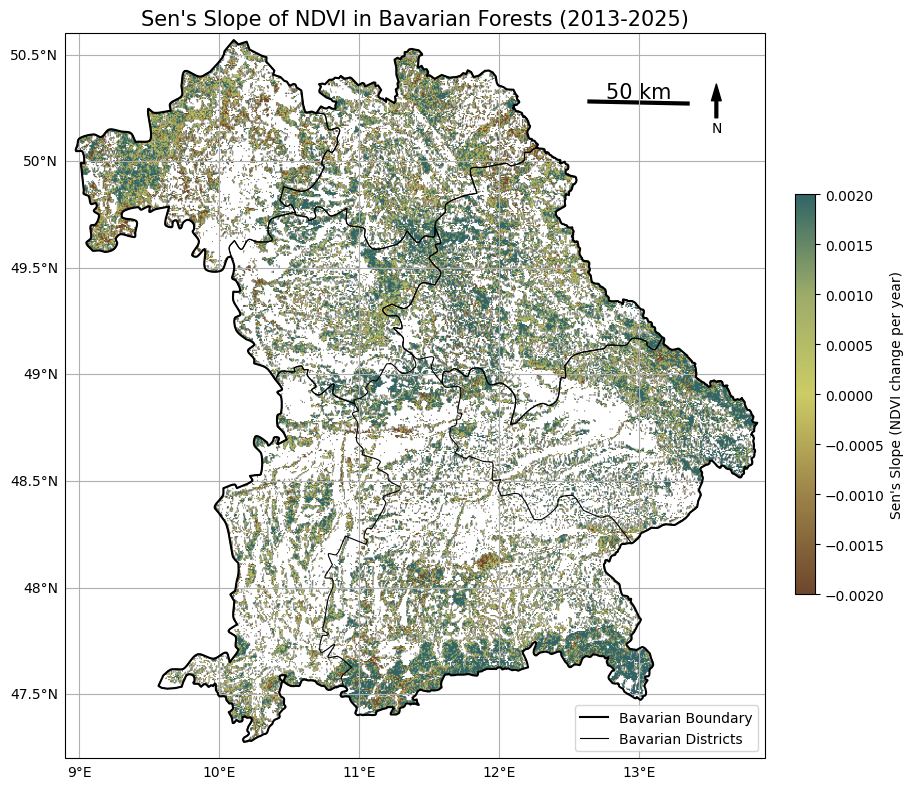

In [14]:
# Sen's Slope Map of NDVI in Bavarian Forests (2013–2025)

fig = plt.figure(figsize=(10,8))

bavaria_region = [13.9, 47.2, 8.9, 50.6] # Define region extent for Bavaria

# Visualization parameters for Sen's Slope
sens_vis = {
    'min': -0.002,
    'max': 0.002,
    'palette': ['#6e462c', '#9c8448', '#cccc66', '#9cab68', '#306466']
}

# Create map of Sen's Slope
ax = cartoee.get_map(
    sens.select('slope'),
    region=bavaria_region,
    vis_params=sens_vis,
    proj=ccrs.PlateCarree()
)

ax.set_aspect(1.5) # avoid map distortion

# Add colorbar
cbar = cartoee.add_colorbar(
    ax, sens_vis,
    loc='right',
    label="Sen's Slope (NDVI change per year)"
)

# Add North Arrow
cartoee.add_north_arrow(
    ax,
    xy=(0.93, 0.93),   # Top right corner
    text="N",
    fontsize=10,       # smaller font for the "N"
    arrow_length=0.06, # optional: scales the arrow itself
    width=2,
    headwidth=7   # optional: thinner arrow
)

# Add scale bar at top right
cartoee.add_scale_bar_lite(
    ax,
    xy=(0.8, 0.9),
    unit="km",
    fontsize=15
)

# Add gridlines
gl = ax.gridlines(draw_labels=True)
gl.bottom_labels = True
gl.left_labels   = True
gl.top_labels    = False
gl.right_labels  = False

# Draw Bavaria boundary (thicker line)
bavaria_gdf.boundary.plot(
    ax=ax,
    edgecolor='black',
    linewidth=1.5,
    zorder=5
)

# Draw districts inside Bavaria (thinner line)
districts_gdf.boundary.plot(
    ax=ax,
    edgecolor='black',
    linewidth=0.8,
    zorder=4
)

# Add Main Title
ax.set_title(label="Sen's Slope of NDVI in Bavarian Forests (2013-2025)", fontsize=15)

# Create custom legend for boundaries
bavaria_line = mlines.Line2D([], [], color='black', linewidth=1.5, label='Bavarian Boundary')
district_line = mlines.Line2D([], [], color='black', linewidth=0.8, label='Bavarian Districts')

ax.legend(handles=[bavaria_line, district_line],
          loc='lower right', fontsize=10, frameon=True)

# Adjust layout and save figure
plt.tight_layout()
plt.savefig("Sensslope_map.png", dpi=300)

plt.show()

